In [1]:
import torch
import random

# Paramètres du MDP
states = [(0,0), (0,1), (1,0), (1,1)]
actions = ['up', 'down', 'left', 'right']
state_idx = {s:i for i,s in enumerate(states)}
n_states = len(states)
n_actions = len(actions)

# Hyperparamètres Q-Learning
gamma = 0.9      # facteur de discount
alpha = 0.1      # taux d'apprentissage
epsilon = 0.2    # exploration
episodes = 500

# Q-table : n_states x n_actions
Q = torch.zeros((n_states, n_actions))

# Fonction de transition et récompense
def transition_reward(s, a):
    x, y = s
    if s == (1,1):
        return s, 0  # état terminal
    if a == 'up':
        next_s = (max(x-1,0), y)
    elif a == 'down':
        next_s = (min(x+1,1), y)
    elif a == 'left':
        next_s = (x, max(y-1,0))
    elif a == 'right':
        next_s = (x, min(y+1,1))
    reward = 1 if next_s == (1,1) else 0
    return next_s, reward

# Q-Learning
for ep in range(episodes):
    s = (0,0)  # état initial
    while s != (1,1):  # épisode jusqu'à état terminal
        i = state_idx[s]
        # Choix d'action : epsilon-greedy
        if random.random() < epsilon:
            a_idx = random.randint(0, n_actions-1)
        else:
            a_idx = torch.argmax(Q[i]).item()
        a = actions[a_idx]

        # Transition
        next_s, r = transition_reward(s, a)
        j = state_idx[next_s]

        # Mise à jour de Q-table
        Q[i, a_idx] = Q[i, a_idx] + alpha * (r + gamma * torch.max(Q[j]) - Q[i, a_idx])

        s = next_s

# Extraction de la politique optimale
policy = {}
for s in states:
    i = state_idx[s]
    if s == (1,1):
        policy[s] = None
    else:
        a_idx = torch.argmax(Q[i]).item()
        policy[s] = actions[a_idx]

# Affichage des résultats
print("Q-table :")
for s in states:
    print(f"{s}: {Q[state_idx[s]]}")

print("\nPolitique optimale :")
for s in states:
    print(f"{s}: {policy[s]}")


Q-table :
(0, 0): tensor([0.7649, 0.5414, 0.7380, 0.9000])
(0, 1): tensor([0.8795, 1.0000, 0.7978, 0.8793])
(1, 0): tensor([0.7471, 0.2015, 0.0654, 0.1900])
(1, 1): tensor([0., 0., 0., 0.])

Politique optimale :
(0, 0): right
(0, 1): down
(1, 0): up
(1, 1): None


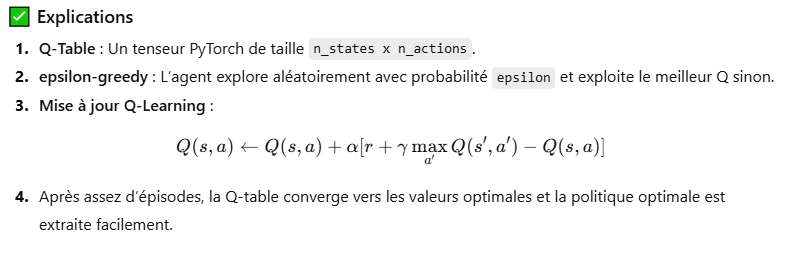